In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('E-commerce Shipping Dataset.csv')
print("First 10 rows of the Dataset")
target = 'Reached.on.Time_Y.N'
df.head(10)

First 10 rows of the Dataset


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [ ]:
accurary_baseline = df['Reached.on.Time_Y.N'].value_counts(normalize=True).max()
print(accurary_baseline)

0.5966906082371125


In [ ]:
df = df.drop('ID', axis=1)

In [ ]:
df.head(5)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


## EDA

In [ ]:
print("Shape of dataset is: ", df.shape)
print(f"Dataset contain {df.shape[0]} rows & {df.shape[1]} columns")

Shape of dataset is:  (10999, 11)
Dataset contain 10999 rows & 11 columns


### Data Spliting

In [ ]:
numerical_data = df.select_dtypes(include=np.number)

numerical_features=numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 7 numerical features: 

['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


In [ ]:
categorical_data = df.select_dtypes(include='object')

categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 4 categorical features: 

['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


### Descriptive Analysis

In [ ]:
numerical_data.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [ ]:
categorical_data.describe()

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


### Variance of numberical features

In [ ]:
numerical_data.var()

,0
Customer_care_calls,1.302999e+00
Customer_rating,1.998274e+00
Cost_of_the_Product,2.310078e+03
Prior_purchases,2.319103e+00
Discount_offered,2.626191e+02
Weight_in_gms,2.674459e+06
Reached.on.Time_Y.N,2.406728e-01


### Skew in numerical values

In [ ]:
numerical_data.skew()

,0
Customer_care_calls,0.391926
Customer_rating,0.004360
Cost_of_the_Product,-0.157117
Prior_purchases,1.681897
Discount_offered,1.798929
Weight_in_gms,-0.249747
Reached.on.Time_Y.N,-0.394257


#### Interpretation

- Customer_care_calls (0.3919) = Slightly Right Skewed
- Customer_rating (0.0044) = Almost symmetrical
- Cost_of_the_product (-0.1571) = Slightly left Skewed
- Prior_purchase (1.682) = Highly Right Skewed. Most people have less than 4 purchases, some has upto 10.
- Discount_offered (1.7989) = Highly Right Skewed. Most orders have 10% discount, some goes up to 65%.
- Weight_in_gms (-0.2497) = Slightly left skewed.
- Reached.on.Time.Y.N (-0.3943) = Slightly left skewed. More orders reach on time.

## Histograms and Box Plot
For finding the outlier and distribution

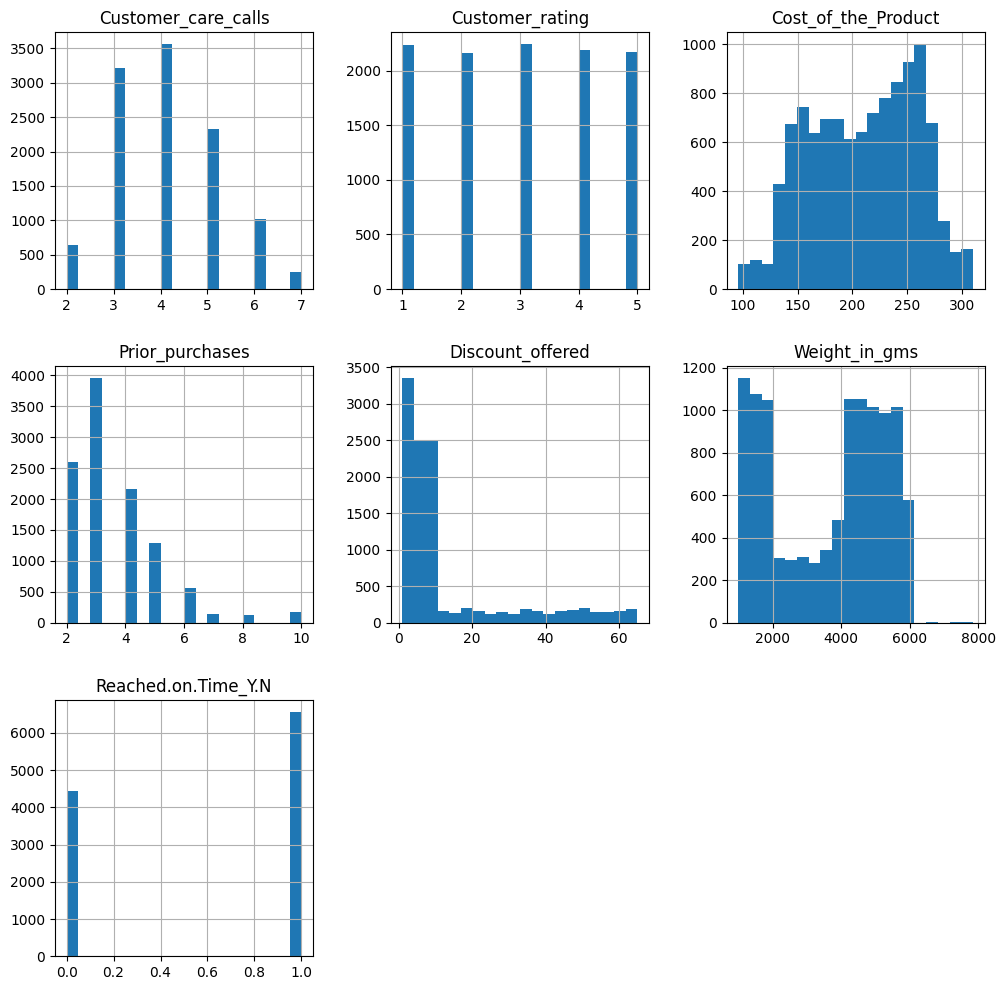

In [ ]:
numerical_data.hist(figsize=(12,12), bins=20)
plt.show()

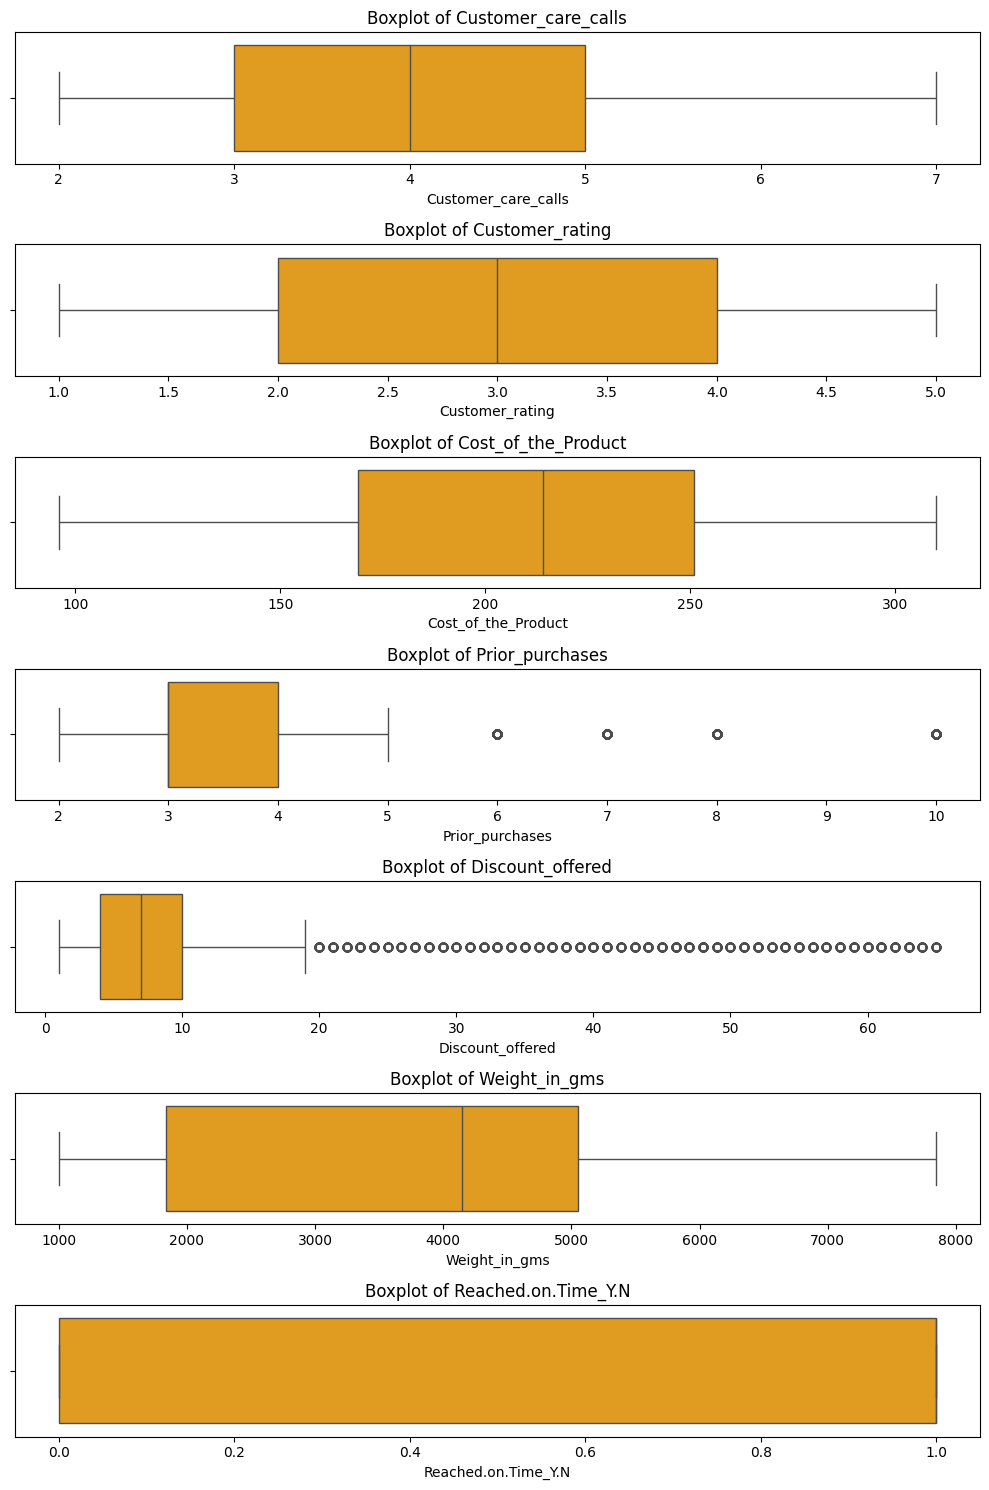

In [ ]:
numeric_cols = numerical_data.columns

plt.figure(figsize=(10, 15))

for i, col in enumerate(numeric_cols, 1):
  plt.subplot(len(numeric_cols), 1, i)
  sns.boxplot(x=df[col], color='orange')
  plt.title(f"Boxplot of {col}", fontsize=12)
  plt.tight_layout()

plt.show()

### Handling Outliers

From the Box plot diagram, we can see outliers in prior purchases and discount offered.

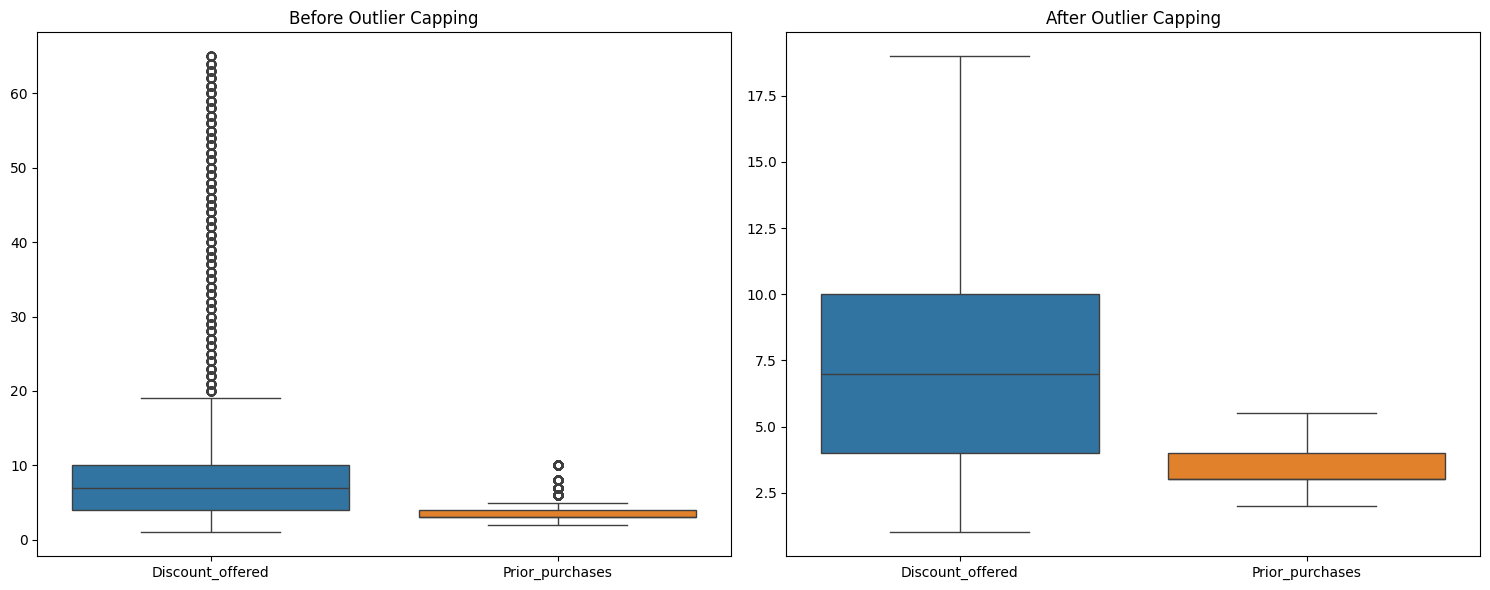

In [ ]:
original_df = df.copy()

def cap_outliers(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    lower_fence = Q1 - 1.5 * IQR

    # Cap upper outliers
    dataframe[column_name] = np.where(
        dataframe[column_name] > upper_fence,
        upper_fence,
        dataframe[column_name]
    )

    return dataframe

df = cap_outliers(df, 'Discount_offered')
df = cap_outliers(df, 'Prior_purchases')


plt.figure(figsize=(15, 6))

# Before capping
plt.subplot(1, 2, 1)
sns.boxplot(data=original_df[['Discount_offered', 'Prior_purchases']])
plt.title('Before Outlier Capping')

# After capping
plt.subplot(1, 2, 2)
sns.boxplot(data=df[['Discount_offered', 'Prior_purchases']])
plt.title('After Outlier Capping')

plt.tight_layout()
plt.show()

### Number of unique values

In [ ]:
numerical_data.nunique()

,0
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Discount_offered,65
Weight_in_gms,4034
Reached.on.Time_Y.N,2


### Missing Values

In [ ]:
numerical_data.isnull().sum()

,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Discount_offered,0
Weight_in_gms,0
Reached.on.Time_Y.N,0


In [ ]:
categorical_data.isnull().sum()

,0
Warehouse_block,0
Mode_of_Shipment,0
Product_importance,0
Gender,0


There are no missing values in the dataset

## Categorical Features

### No of unique values in each features

In [ ]:
categorical_data.nunique()

,0
Warehouse_block,5
Mode_of_Shipment,3
Product_importance,3
Gender,2


### Bar plot of unique value count

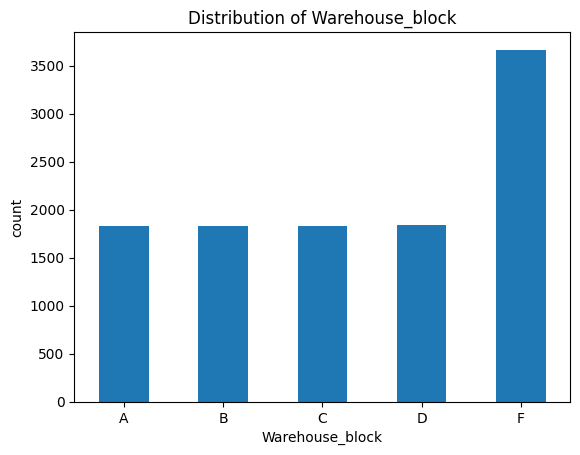

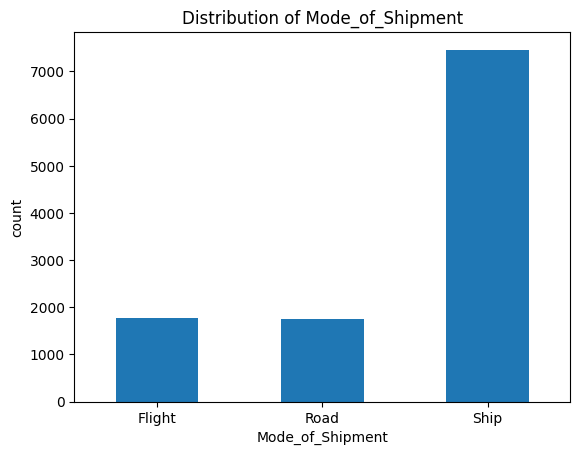

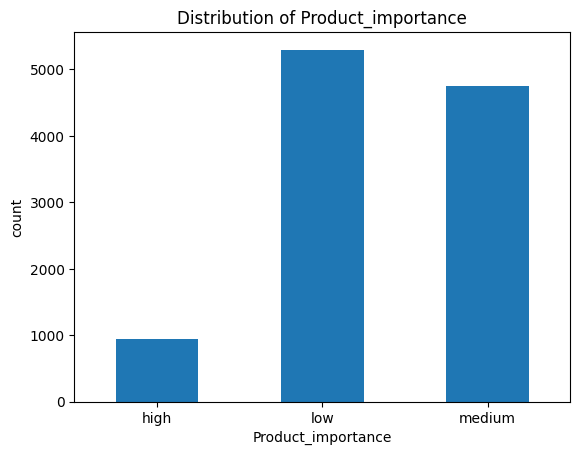

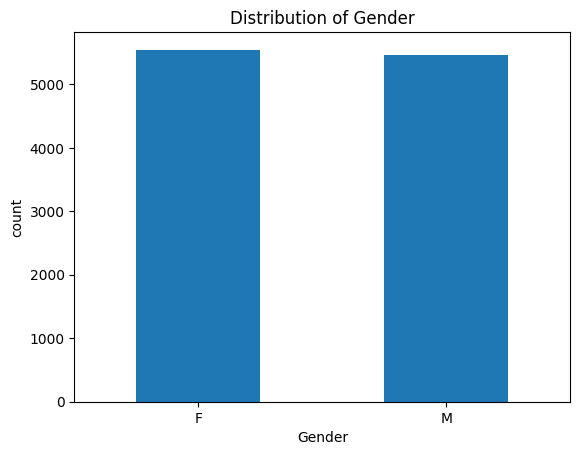

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

## Correlation Analysis

**Correlation matrix for numerical data**

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Customer_care_calls,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


**HEATMAP**

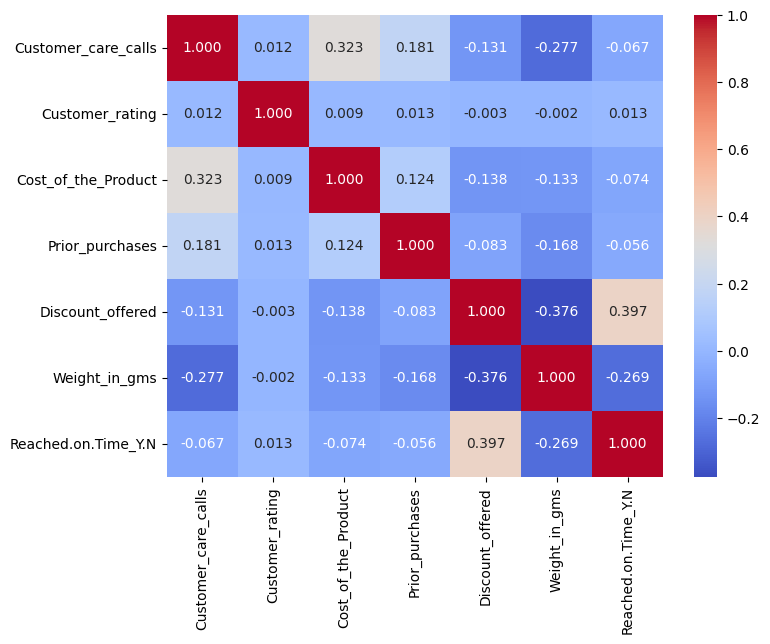

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.3f' )
plt.show()

What do you understand after the correlation test?
- The heatmap reveals a few key relationships. The most significant is the negative correlation of (-0.40) between Discount_offered and the target Reached.on.Time_Y.N. This indicates that shipments with higher discounts are less likely to arrive on time. Another moderate correlation is between Cost_of_the_Product and Customer_care_calls (0.32), suggesting customers may call more often for higher-cost products.

### Correlation plot between numerical features and target using different methods

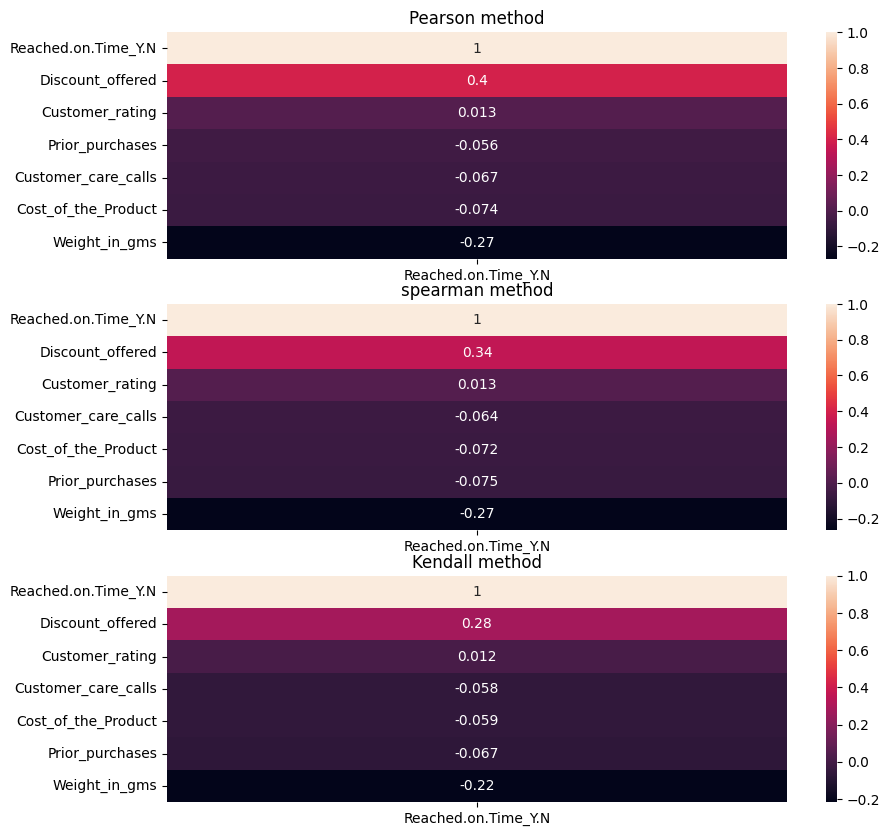

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))

corr1 = numerical_data.corr('pearson')[[target]].sort_values(by=target, ascending=False)
corr2 = numerical_data.corr('spearman')[[target]].sort_values(by=target, ascending=False)
corr3 = numerical_data.corr('kendall')[[target]].sort_values(by=target, ascending=False)

ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

How many features?
- There are 12 columns. We will drop the 'ID' column, leaving us with 10 features (independent variables) and 1 target variable.

Classification or regression problem?
-  This is a binary classification problem because the target variable, Reached.on.Time_Y.N, can only have two outcomes: 1 (Yes) or 0 (No).

How many data points?
- The dataset contains 10,999 data points (rows).

What kind of features?
- Categorical: Warehouse_block, Mode_of_Shipment, Product_importance, Gender.

- Quantitative (Numerical): Customer_care_calls, Customer_rating, Cost_of_the_Product, Prior_purchases, Discount_offered, Weight_in_gms.

Do you need to encode categorical variables?
- Yes, because machine learning models require all input features to be in a numerical format.

## Imbalanced Dataset

Class Distribution:
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


/tmp/ipython-input-2669527817.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='pastel')


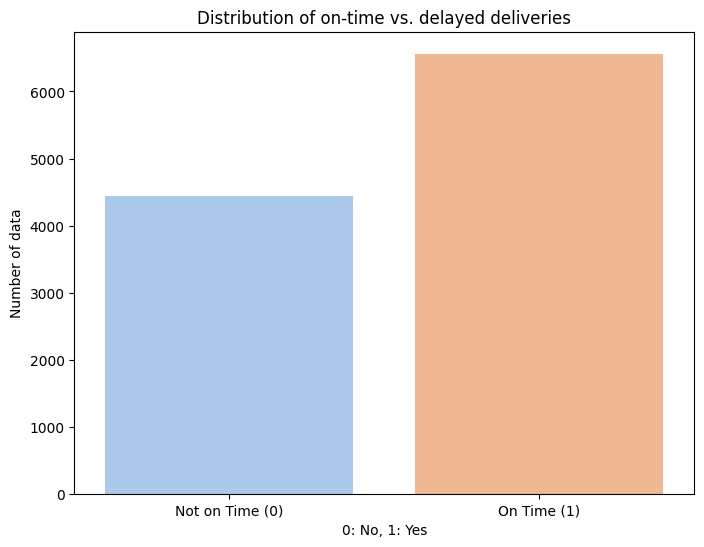

In [ ]:
class_counts = df[target].value_counts()
print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='pastel')
plt.title('Distribution of on-time vs. delayed deliveries')
plt.xlabel('0: No, 1: Yes')
plt.ylabel('Number of data')
plt.xticks(ticks=[0,1], labels=['Not on Time (0)', 'On Time (1)'])
plt.show()

Do all unique classes have an equal number of instances?
- No, the classes are not perfectly balanced. There are 6,563 instances of shipments arriving on time (Class 1) and 4,436 instances of delayed shipments (Class 0). While not severely imbalanced, this is an important characteristic of the dataset to note.

## Dataset Splitting
- Training Set 70%
- Testing Set 30%

As our target feature is not perfectly balanced, we will use **Stratified Splitting**. Stratified splitting ensures that our training and test sets will have the same percentage of 0 & 1 as the original dataset.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (7699, 10)
Shape of y_train: (7699,)
Shape of X_test: (3300, 10)
Shape of y_test: (3300,)


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

numerical_features_X = X.select_dtypes(include=np.number).columns.tolist()
one_hot_features = ['Warehouse_block', 'Mode_of_Shipment', 'Gender']
ordinal_features = ['Product_importance']

importance_order = ['low', 'medium', 'high']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_X),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_features),
        ('cat_ordinal', OrdinalEncoder(categories=[importance_order]), ordinal_features)
    ],
    remainder='passthrough'
)


X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing successful using the scikit-learn pipeline!")
print("Shape of processed training data:", X_train_processed.shape)
print("Shape of processed testing data:", X_test_processed.shape)

Preprocessing successful using the scikit-learn pipeline!
Shape of processed training data: (7699, 17)
Shape of processed testing data: (3300, 17)


### From the above inspection:
- `Product_importance` has values `['low','medium', 'high']`. These values have a clear, logical order. Thus, we will use **Ordinal Encoding**.<br><br>
- Other categorical columns such as `Warehouse_block`,  `Mode_of_Shipment`, and `Gender` do not have intrinsic order. Therefore, we will use **One-Hot Encoding**.

### Class Imbalance Handling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

print("Shape of training data before SMOTE:", X_train_processed.shape)
print("Class distribution before SMOTE:\n", y_train.value_counts())

X_train_resampled, y_train_resampled = rus.fit_resample(X_train_processed, y_train)

print("\nShape of training data after SMOTE:", X_train_resampled.shape)
print("Class distribution after SMOTE:\n", y_train_resampled.value_counts())


Shape of training data before SMOTE: (7699, 17)
Class distribution before SMOTE:
 Reached.on.Time_Y.N
1    4594
0    3105
Name: count, dtype: int64

Shape of training data after SMOTE: (6210, 17)
Class distribution after SMOTE:
 Reached.on.Time_Y.N
0    3105
1    3105
Name: count, dtype: int64


# Supervised Learning

## 1. Logistic Regression
We will start by implementing a logistic regression model. It is a simple, fast and highly interpretable model.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

param_grid_lr = {
    'C': [0.1, 0.5, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'saga'] # Solvers
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy', verbose=1)

print("Running GridSearchCV for Logistic Regression...")
grid_lr.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV complete.")

print("\nBest Parameters for Logistic Regression:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)

best_lr_model = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test_processed)
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)

print(f"\nTuned Logistic Regression Model Accuracy on Test Set: {accuracy_lr_tuned:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV complete.

Best Parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.6578099838969405

Tuned Logistic Regression Model Accuracy on Test Set: 0.6512


## Decision Tree
Making predictions based on a series of "if-else" questions.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', verbose=1)

print("Running GridSearchCV for Decision Tree...")
grid_dt.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV complete.")

print("\nBest Parameters for Decision Tree:", grid_dt.best_params_)
print("Best Cross-Validation Accuracy:", grid_dt.best_score_)

best_dt_model = grid_dt.best_estimator_
y_pred_dt_tuned = best_dt_model.predict(X_test_processed)
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)

print(f"\nTuned Decision Tree Model Accuracy on Test Set: {accuracy_dt_tuned:.4f}")

Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV complete.

Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.7273752012882448

Tuned Decision Tree Model Accuracy on Test Set: 0.6791


## Neural Network
A complex model inspired by human brain, capable of learning intricate patterns in data.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn_model_updated = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


nn_model_updated.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])


print("Training the updated Neural Network model...")
history_updated = nn_model_updated.fit(X_train_resampled, y_train_resampled, epochs=25, batch_size=32, verbose=0)
print("Training complete.")

loss_updated, accuracy_nn_updated = nn_model_updated.evaluate(X_test_processed, y_test, verbose=0)

print(f"\nUpdated Neural Network Model Accuracy: {accuracy_nn_updated:.4f}")

Training the updated Neural Network model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training complete.

Updated Neural Network Model Accuracy: 0.6679


## KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': [2, 3, 4, 5, 7, 9, 11, 15]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid_knn.fit(X_train_resampled, y_train_resampled)

print("Best k for KNN:", grid_knn.best_params_)
print("Best F1-score (CV):", grid_knn.best_score_)




Best k for KNN: {'n_neighbors': 3}
Best F1-score (CV): 0.6294548942444146


In [ ]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

knn_model = grid_knn.best_estimator_

print("Training KNN model...")
knn_model.fit(X_train_resampled, y_train_resampled)
print("Training complete.")

y_pred_knn = knn_model.predict(X_test_processed)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test_processed)[:,1])

print(f"\nKNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN F1-score: {f1_knn:.4f}")
print(f"KNN ROC-AUC: {auc_knn:.4f}")


Training KNN model...
Training complete.

KNN Accuracy: 0.6497
KNN F1-score: 0.6699
KNN ROC-AUC: 0.7082


## Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(best_lr_model, X_train_resampled, y_train_resampled, cv=cv, scoring='f1')
print("Logistic Regression Mean F1-score (CV):", cv_scores_lr.mean())

cv_scores_dt = cross_val_score(best_dt_model, X_train_resampled, y_train_resampled, cv=cv, scoring='f1')
print("Decision Tree Mean F1-score (CV):", cv_scores_dt.mean())


Logistic Regression Mean F1-score (CV): 0.619325364318159
Decision Tree Mean F1-score (CV): 0.6437005173272373


# Unsupervised Learning

## K-Means
Clustering

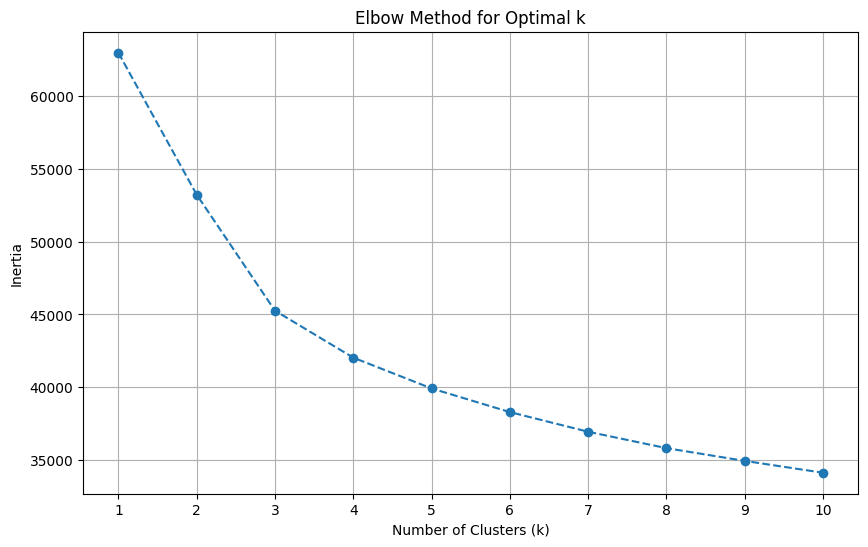

In [ ]:
# The Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_processed)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**3** is the elbow point in the curve

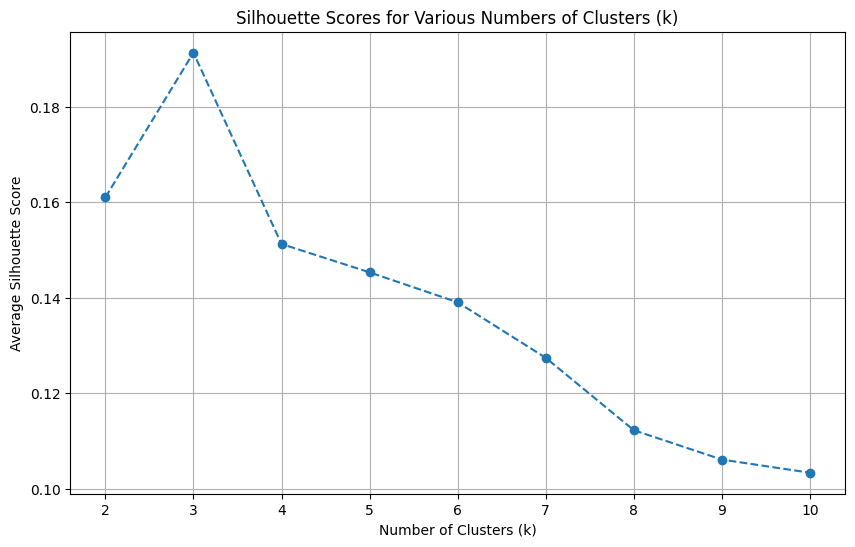

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_processed)
    score = silhouette_score(X_train_processed, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Various Numbers of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

This makes it even clearer, **3** shows the highest Silhoutte value

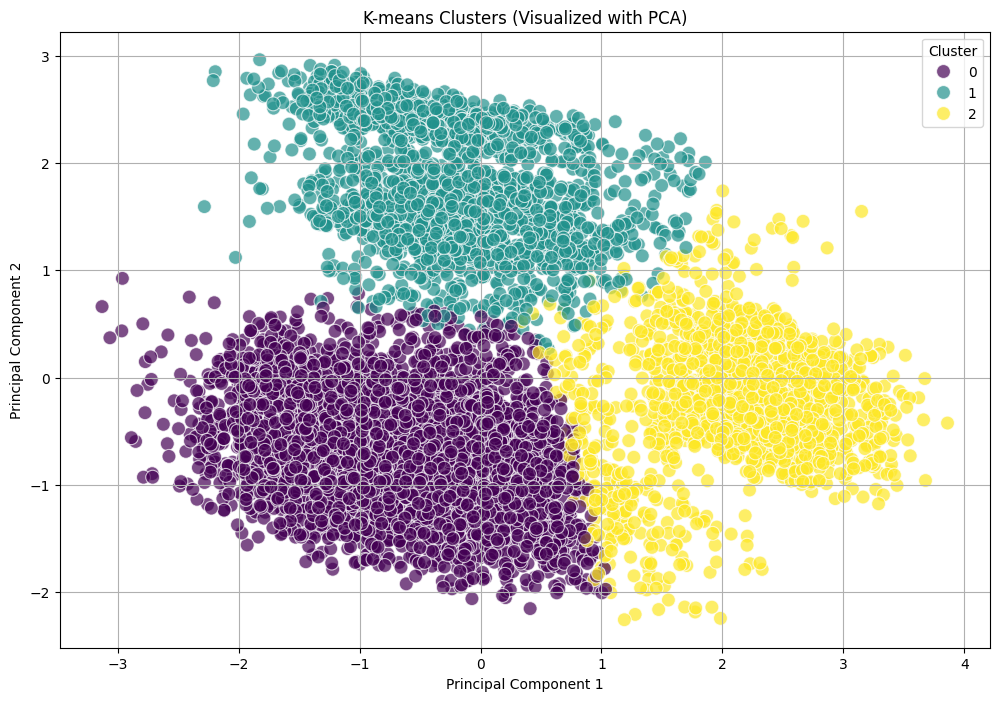

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_processed)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)

pca_df = pd.DataFrame(data=X_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('K-means Clusters (Visualized with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_train_processed, cluster_labels)

print(f"The silhouette score for our 3-cluster solution is: {score:.4f}")

The silhouette score for our 3-cluster solution is: 0.1913


In [ ]:
import numpy as np

X_train_with_clusters = X_train.copy()
X_train_with_clusters['Cluster'] = cluster_labels

numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cluster_summary = X_train_with_clusters.groupby('Cluster')[numerical_cols].mean()

print("--- Cluster Profiles (Feature Averages) ---")
cluster_summary

--- Cluster Profiles (Feature Averages) ---


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
Cluster,,,,,,
0,3.730870,2.969964,200.172825,3.131943,5.454350,4858.483909
1,3.677824,2.988494,193.317469,3.054132,17.739540,2303.257845
2,5.321608,3.060930,255.704146,4.660490,6.015075,2003.618719


- Cluster 0: Heavy Shipments. These are orders with significantly heavier products.

- Cluster 1: High-Discount Orders. These orders are defined by the large discounts offered.

- Cluster 2: High Customer Interaction. These orders generate more customer care calls.

# Model selection/Comparison Analysis

## Accuracy Comparison Bar Chart

/tmp/ipython-input-1555161197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies.index, y=accuracies.values, palette='pastel')


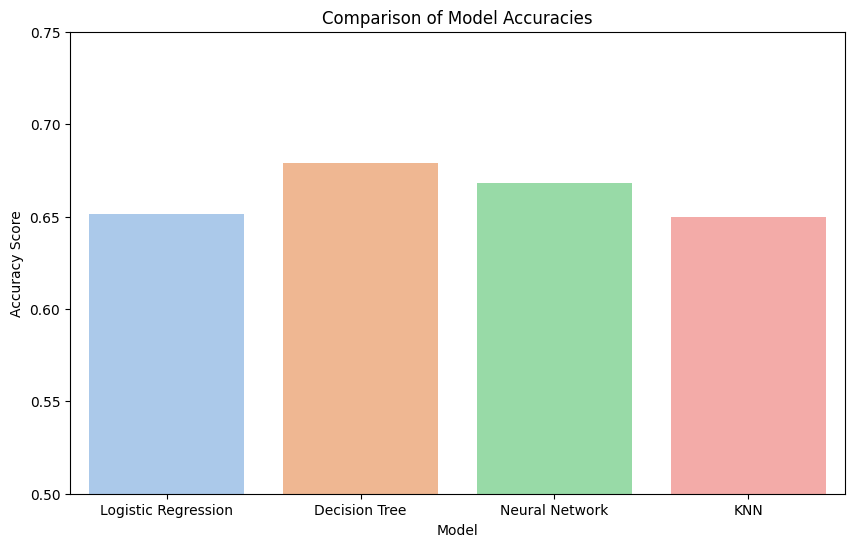

,0
Logistic Regression,0.651212
Decision Tree,0.679091
Neural Network,0.667879
KNN,0.649697


In [ ]:
model_accuracies = {
    'Logistic Regression': accuracy_lr_tuned,
    'Decision Tree': accuracy_dt_tuned,
    'Neural Network': accuracy_nn_updated,
    'KNN': accuracy_knn
}

accuracies = pd.Series(model_accuracies)

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies.index, y=accuracies.values, palette='pastel')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.5, 0.75)
plt.show()

accuracies

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.55      0.78      0.64      1331
           1       0.79      0.56      0.66      1969

    accuracy                           0.65      3300
   macro avg       0.67      0.67      0.65      3300
weighted avg       0.69      0.65      0.65      3300


--- Classification Report for Decision Tree ---
              precision    recall  f1-score   support

           0       0.56      0.97      0.71      1331
           1       0.96      0.48      0.64      1969

    accuracy                           0.68      3300
   macro avg       0.76      0.73      0.68      3300
weighted avg       0.80      0.68      0.67      3300


--- Classification Report for Neural Network ---
              precision    recall  f1-score   support

           0       0.55      0.98      0.70      1331
           1       0.97      0.45      0.

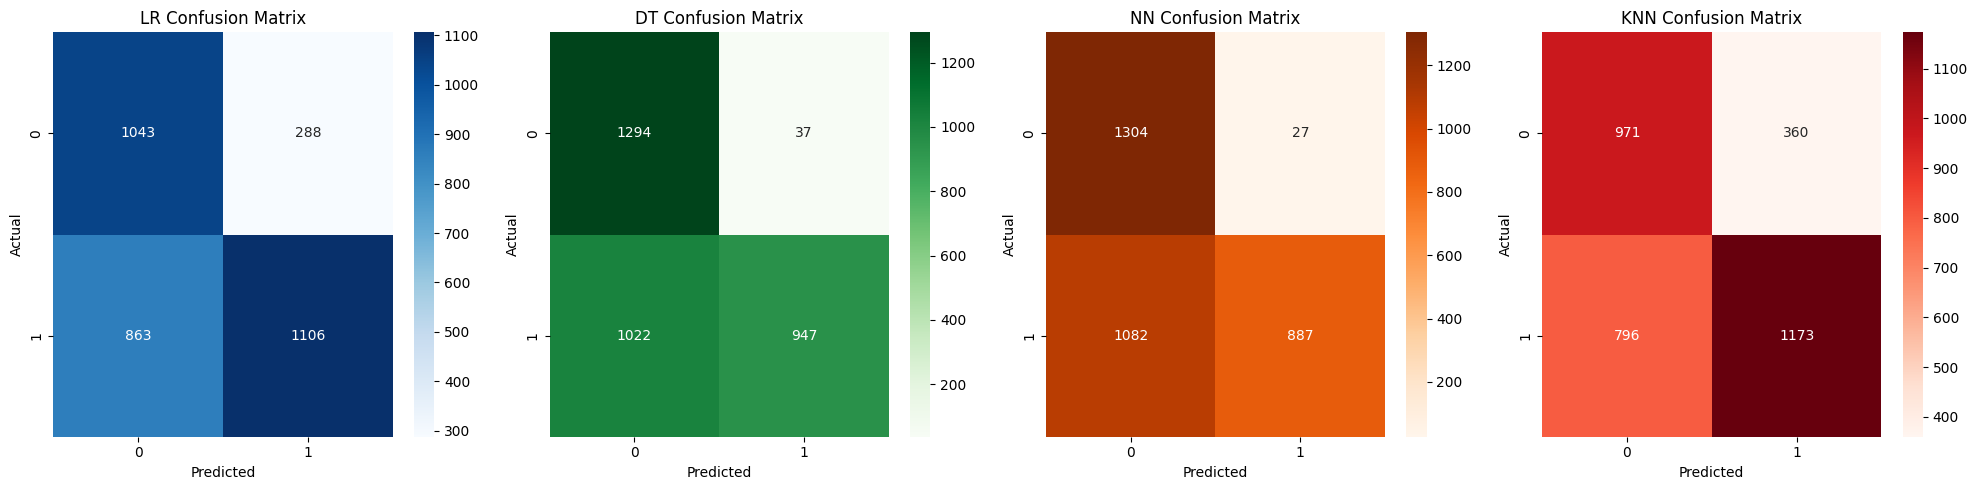

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_nn_prob = nn_model_updated.predict(X_test_processed)
y_pred_nn = (y_pred_nn_prob > 0.6).astype(int).flatten()

# Print Classification Reports
print("--- Classification Report for Logistic Regression ---")
report_lr = classification_report(y_test, y_pred_lr_tuned, output_dict=True)
print(classification_report(y_test, y_pred_lr_tuned))

print("\n--- Classification Report for Decision Tree ---")
report_dt = classification_report(y_test, y_pred_dt_tuned, output_dict=True)
print(classification_report(y_test, y_pred_dt_tuned))

print("\n--- Classification Report for Neural Network ---")
report_nn = classification_report(y_test, y_pred_nn, output_dict=True)
print(classification_report(y_test, y_pred_nn))

print("\n--- Classification Report for KNN ---")
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(classification_report(y_test, y_pred_knn))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_tuned)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('LR Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt_tuned)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('DT Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Neural Network Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('NN Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

# KNN Network Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', ax=axes[3])
axes[3].set_title('KNN Confusion Matrix')
axes[3].set_xlabel('Predicted')
axes[3].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Precision and Recall Bar Graph

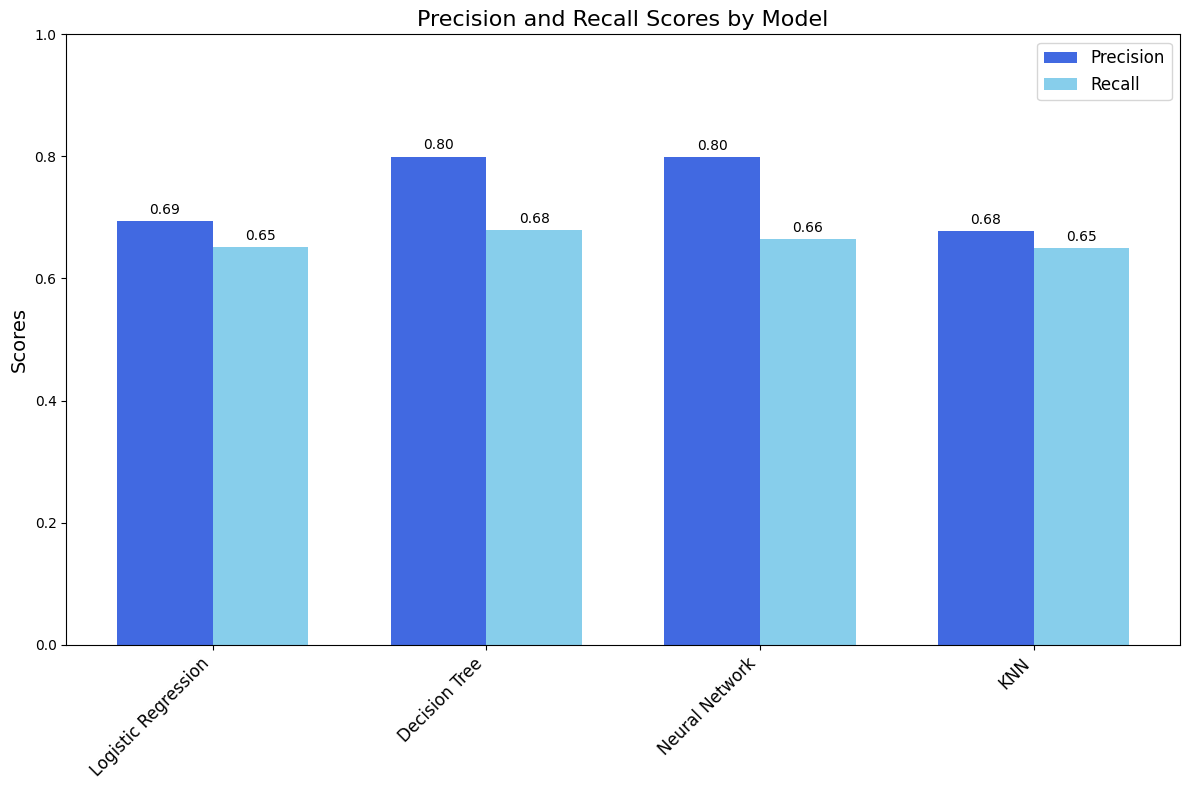

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Neural Network','KNN']

precision_scores = [
    report_lr['weighted avg']['precision'],
    report_dt['weighted avg']['precision'],
    report_nn['weighted avg']['precision'],
    report_knn['weighted avg']['precision']
]

recall_scores = [
    report_lr['weighted avg']['recall'],
    report_dt['weighted avg']['recall'],
    report_nn['weighted avg']['recall'],
    report_knn['weighted avg']['recall']
]


x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# Precision
rects1 = ax.bar(x - width/2, precision_scores, width, label='Precision', color='royalblue')
# Recall
rects2 = ax.bar(x + width/2, recall_scores, width, label='Recall', color='skyblue')

ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Precision and Recall Scores by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right", fontsize=12)
ax.legend(fontsize=12)

ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

## ROC Curve Comparison

Logistic Regression AUC: 0.7172
Decision Tree AUC: 0.7324
Neural Network AUC: 0.7323
KNN AUC: 0.7082


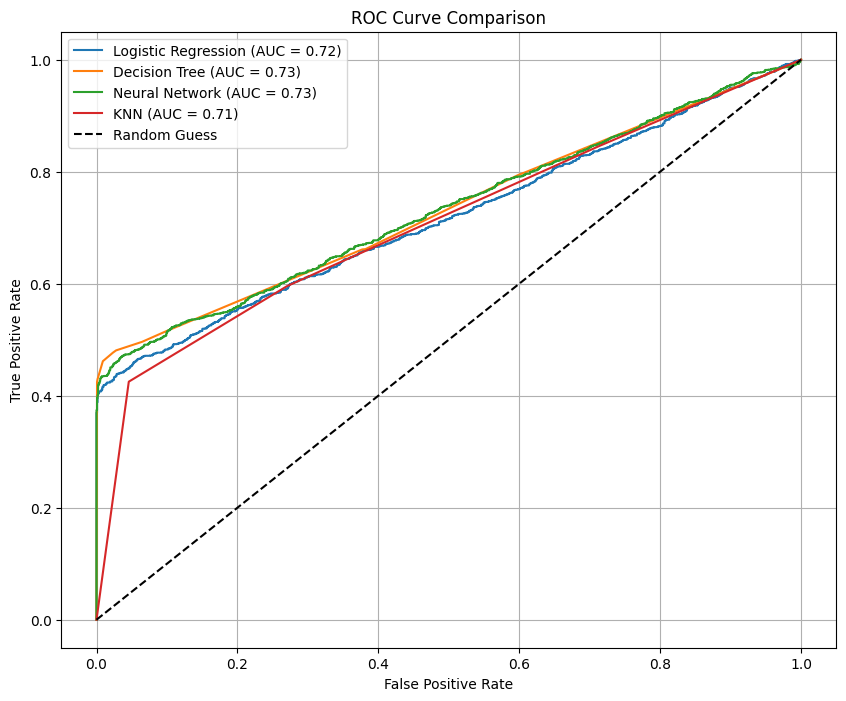

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
y_prob_lr = best_lr_model.predict_proba(X_test_processed)[:, 1]
# Decision Tree
y_prob_dt = best_dt_model.predict_proba(X_test_processed)[:, 1]
# Neural Network
y_prob_nn = y_pred_nn_prob.flatten()

y_prob_knn = knn_model.predict_proba(X_test_processed)[:,1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_nn = roc_auc_score(y_test, y_prob_nn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Decision Tree AUC: {auc_dt:.4f}")
print(f"Neural Network AUC: {auc_nn:.4f}")
print(f"KNN AUC: {auc_knn:.4f}")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)


plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()